# Phase 1 — Baseline RF Per-Day Evaluation

**Notebook:** `notebooks/01_phase0_foundation/06_baseline_rf_per_day.ipynb`

**Empirical question:** When a Random Forest IDS is trained on early-week traffic (Mon + a small Tuesday sample), how does its attack-detection recall behave as the week progresses and the attack-distribution drifts?

**Headline finding (locked in this notebook, used by Phase 1+ experiments):** *Drift, not class imbalance, is the dominant cause of failure.* Class-imbalance interventions (balanced weights, downsampling) recover essentially zero recall (+0.001) over the raw cold-start baseline. The model needs to *learn* post-drift attack signatures, not just be told to weight rare classes more heavily.

### Five baselines computed here

| Baseline | Trained on | Purpose |
|---|---|---|
| **cold_start** | Mon + 5% Tue | Naive deployed IDS (default RF, ~0.09% attack training rate) |
| **cold_start_balanced** | Mon + 5% Tue | Same data, `class_weight='balanced'` — isolates the weighting effect |
| **cold_start_downsampled** | Mon-benign downsampled to ~100:1 + 5% Tue | Same model, less-imbalanced training set |
| **realistic** | Mon + 50% Tue | More data, still single-day attack exposure |
| **oracle** | Stratified across all 5 days | Upper-bound ceiling (impossible in real-time) |

Why all five? Because reviewers will challenge any conclusion. *cold_start* is the failure case. *balanced* and *downsampled* control for class imbalance. *realistic* controls for training-set size. *oracle* is the ceiling. Together they isolate drift as the only remaining mechanism.

### Runtime configuration

**Use CPU runtime, not GPU.** Random Forest and TreeSHAP are CPU-only.
1. Runtime → Change runtime type
2. Hardware accelerator: **None (CPU)**
3. Runtime shape: **High-RAM** (Colab Pro+; ~50 GB RAM)

### Idempotent re-run

Models with `.joblib` checkpoints load from disk; only missing models retrain. To force retraining, delete the file from `experiments/checkpoints/`.

### Deliverables

- Recall trajectory → `reports/figures/06_recall_trajectory.{png,pdf}`
- Multi-threshold sweep → `reports/figures/06_threshold_sweep.{png,pdf}`
- Per-attack heatmap → `reports/figures/06_per_attack_recall_wednesday.{png,pdf}`
- Per-day metrics → `reports/tables/06_baseline_metrics.csv`
- Per-attack-category breakdown → `reports/tables/06_per_attack_category_recall.csv`
- Threshold sweep table → `reports/tables/06_threshold_sweep.csv`
- Trained models → `experiments/checkpoints/rf_*.joblib`
- Decisions D012, D013, D014, D015, D016 → `decisions_log.md`

### ⚠️ Before running: clean prior D015 entry if present

If you ran a previous version of this notebook that auto-classified D015 as "mixed", manually delete that entry from `reports/advisor_notes/decisions_log.md` before re-running. The new D015 logs the corrected drift-dominant finding directly. The notebook will warn and skip if a D015 already exists — leaving you with a stale entry.

## 1. Setup + paper-quality plotting defaults

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')

%pip install -q joblib

Mounted at /content/drive


In [2]:
import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, average_precision_score,
)
from sklearn.model_selection import train_test_split

from src.data.loaders import (
    load_cicids2017, cicids2017_day_stream, CICIDS2017_DAY_ORDER,
)
from src.utils.seeding import set_global_seed

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
CHECKPOINTS = ROOT / 'experiments' / 'checkpoints'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_06_baseline.json'

for p in [FIGURES, TABLES, CHECKPOINTS]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
set_global_seed(SEED)
rng = np.random.default_rng(SEED)

# ----- Paper-quality plotting defaults -----
# Applied globally to every figure in this notebook.
# Targets Q1-journal figure requirements: 300 DPI, serif font, white bg.
PAPER_RCPARAMS = {
    'figure.dpi': 110,                   # screen rendering
    'savefig.dpi': 300,                  # final file dpi (Q1 standard)
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.8,
    'lines.markersize': 6,
    'pdf.fonttype': 42,                  # embed TrueType fonts (LaTeX-friendly)
    'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)

# Colorblind-safe palette (Wong 2011 / Okabe-Ito) for the 5 baselines
# https://www.nature.com/articles/nmeth.1618
PALETTE = {
    'cold_start':             '#D55E00',  # vermillion
    'cold_start_balanced':    '#E69F00',  # orange
    'cold_start_downsampled': '#F0E442',  # yellow
    'realistic':              '#0072B2',  # blue
    'oracle':                 '#009E73',  # green
}
MARKERS = {
    'cold_start':             'o',
    'cold_start_balanced':    's',
    'cold_start_downsampled': 'D',
    'realistic':              'v',
    'oracle':                 '^',
}
MODEL_DISPLAY = {  # camera-ready labels for figures
    'cold_start':             'Cold-start',
    'cold_start_balanced':    'Cold-start (balanced)',
    'cold_start_downsampled': 'Cold-start (downsampled)',
    'realistic':              'Realistic',
    'oracle':                 'Oracle',
}

def save_figure(fig, name: str):
    """Save a figure as both PNG (for slides/docs) and PDF (for LaTeX)."""
    fig.savefig(FIGURES / f'{name}.png')
    fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {FIGURES / f"{name}.png"}')
    print(f'  saved: {FIGURES / f"{name}.pdf"}')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='06_baseline_rf_per_day'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists():
        existing = DECISIONS_LOG.read_text()
        if f'## {decision_id} \u2014' in existing:
            print(f'[DECISION SKIPPED] {decision_id} already logged. '
                  f'If you want to update it, manually remove the existing entry.')
            return
    entry = (
        f'\n## {decision_id} \u2014 {today}\n'
        f'**Context:** `{context}`\n\n'
        f'**Decision:** {decision}\n\n'
        f'**Rationale:** {rationale}\n\n'
    )
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}: {decision[:80]}...')

SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'seed': SEED,
    'runtime': 'CPU + High-RAM (no GPU)',
}
print('Setup complete. Seed:', SEED)

Setup complete. Seed: 42


## 2. Pre-registered success criteria — D012

Commit in writing to what counts as success / modest / weak for the Phase 1 method *before* running any baseline. Protects against post-hoc reinterpretation.

| Outcome | precision@K vs ground-truth drifted set | vs prediction-disagreement baseline | Interpretation |
|---|---|---|---|
| **Strong** | > 0.70 | beats baseline by ≥ 0.20 | Method works on real data. Target KBS/ESWA/EAAI. |
| **Modest** | 0.40 – 0.70 | beats baseline by 0.05 – 0.20 | Narrow contribution. Workshop or IEEE Access. |
| **Weak** | ≤ baseline | no margin | Pivot the thesis claim toward 'why explanation methods fail under realistic drift'. |

Ground-truth drifted set = top-K features by mean KS-D from notebook 05 (see D008).

In [3]:
log_decision(
    decision_id='D012',
    decision=('Pre-registered Phase 1 success thresholds: STRONG = SHAP localization '
              'precision@K > 0.70 AND beats prediction-disagreement baseline by '
              '\u2265 0.20. MODEST = precision@K 0.40\u20130.70 AND beats baseline by '
              '0.05\u20130.20. WEAK = precision@K \u2264 baseline. Outcome class will '
              'determine paper venue and thesis framing.'),
    rationale=('Synthetic v3/v4 experiments yielded precision@K = 1.0 on '
               'localization, but real CICIDS2017 has KS drift peaking at 0.45. '
               'Real-data results will be substantially weaker than synthetic. '
               'Pre-registering thresholds prevents post-hoc reinterpretation.'),
    alternatives=('No pre-registration (rejected: invites motivated reasoning). '
                  'Single threshold (rejected: outcomes naturally three-tiered).'),
)

[DECISION SKIPPED] D012 already logged. If you want to update it, manually remove the existing entry.


## 3. Load Monday and Tuesday (shared by multiple training sets)

Apply the constant-feature drop from D009. Establish the canonical `FEATURE_COLS` order.

In [4]:
X_mon, y_mon, meta_mon = load_cicids2017(day='monday')
X_tue, y_tue, meta_tue = load_cicids2017(day='tuesday')

with open(ROOT / 'data' / 'processed' / 'cicids2017_characterized.json') as f:
    char_summary = json.load(f)
constant_features = char_summary.get('low_variance', {}).get('constant_features', [])

X_mon = X_mon.drop(columns=constant_features, errors='ignore')
X_tue = X_tue.drop(columns=constant_features, errors='ignore')
FEATURE_COLS = X_mon.columns.tolist()

print(f'Monday:  {len(X_mon):,} rows, {X_mon.shape[1]} features, attacks={(y_mon==1).sum():,}')
print(f'Tuesday: {len(X_tue):,} rows, {X_tue.shape[1]} features, attacks={(y_tue==1).sum():,}')

Monday:  371,621 rows, 82 features, attacks=0
Tuesday: 322,078 rows, 82 features, attacks=6,972


## 4. D013 — The cold-start framing

Pure Monday-only training is impossible (single class). Naive baseline becomes "cold-start" = Mon + 5% Tue.

In [5]:
log_decision(
    decision_id='D013',
    decision=('"Naive" baseline is renamed "cold-start" \u2014 trained on Monday + '
              '5% stratified sample of Tuesday. Pure Monday-only training is '
              'impossible because RF requires at least 2 classes.'),
    rationale=('Monday has 0% attack rate. A 5% Tuesday sample (~16k rows) gives '
               'minimal attack exposure, simulating a freshly deployed IDS.'),
    alternatives=('SMOTE oversampling (rejected: synthetic bias). 50% of Tuesday '
                  '(rejected: too close to realistic baseline).'),
)

tue_sample_idx, _ = train_test_split(
    np.arange(len(y_tue)), train_size=0.05, stratify=y_tue, random_state=SEED,
)
X_cold_start = pd.concat([X_mon, X_tue.iloc[tue_sample_idx]], ignore_index=True)
y_cold_start = pd.concat([y_mon, y_tue.iloc[tue_sample_idx]], ignore_index=True)

print(f'Cold-start training set:')
print(f'  rows:     {len(X_cold_start):,}')
print(f'  attacks:  {int((y_cold_start==1).sum()):,} ({(y_cold_start==1).mean():.4%})')
print(f'  features: {X_cold_start.shape[1]}')

[DECISION SKIPPED] D013 already logged. If you want to update it, manually remove the existing entry.
Cold-start training set:
  rows:     387,724
  attacks:  349 (0.0900%)
  features: 82


## 5. D014 — Class-imbalance control baselines

Cold-start has 0.000 recall on Wed/Thu/Fri with max attack probability ~0.16. Two competing hypotheses:

- **Drift:** Wed/Thu/Fri attacks (DoS, Portscan, etc.) have feature signatures different from the Tuesday brute-force attacks the model trained on.
- **Class imbalance:** 0.09% attack rate in training makes RF systematically prefer the benign class.

We add two baselines that control for imbalance: `cold_start_balanced` (`class_weight='balanced'`) and `cold_start_downsampled` (Monday benigns randomly downsampled to ~100:1 against attacks). Same drift exposure, different imbalance handling.

In [6]:
log_decision(
    decision_id='D014',
    decision=('Add cold_start_balanced (class_weight="balanced") and '
              'cold_start_downsampled (benign:attack ratio ~100:1 via random '
              'downsampling) as additional baselines. Same drift exposure as '
              'cold_start, different class-imbalance handling.'),
    rationale=('First-run diagnostics showed cold_start max attack probability '
               'is 0.16. We need to test whether imbalance handling alone '
               'recovers recall. If yes, the SHAP method must beat THE BALANCED '
               'BASELINE, not the raw cold_start. If no, drift is the dominant '
               'mechanism.'),
    alternatives=('SMOTE/SMOTEENN (rejected: synthetic data biases SHAP outputs). '
                  'Threshold tuning only (rejected: max proba is 0.16 on Wed '
                  '\u2014 no threshold can recover what is not predicted).'),
)

[DECISION SKIPPED] D014 already logged. If you want to update it, manually remove the existing entry.


## 6. Train all five baseline models

Idempotent. Existing checkpoints load from disk; only missing models train.

In [7]:
RF_PARAMS = dict(n_estimators=100, max_depth=12, n_jobs=-1, random_state=SEED)
SUMMARY['rf_hyperparameters'] = RF_PARAMS
training_times = {}

def train_or_load(name: str, X, y, extra_params=None):
    checkpoint = CHECKPOINTS / f'rf_{name}.joblib'
    params = {**RF_PARAMS, **(extra_params or {})}
    if checkpoint.exists():
        rf = joblib.load(checkpoint)
        training_times[name] = None
        print(f'  [load] {name}: existing checkpoint ({checkpoint.stat().st_size/1024**2:.1f} MB)')
        return rf
    print(f'  [train] {name}: {len(X):,} rows, {int((y==1).sum()):,} attacks...')
    t0 = time.time()
    rf = RandomForestClassifier(**params).fit(X, y)
    dt = time.time() - t0
    training_times[name] = dt
    joblib.dump(rf, checkpoint)
    print(f'           done in {dt:.1f}s, saved to {checkpoint.name}')
    return rf

# --- 1. cold_start ---
rf_cold = train_or_load('cold_start', X_cold_start, y_cold_start)

# --- 2. cold_start_balanced ---
rf_balanced = train_or_load('cold_start_balanced', X_cold_start, y_cold_start,
                            extra_params=dict(class_weight='balanced'))

# --- 3. cold_start_downsampled ---
ds_checkpoint = CHECKPOINTS / 'rf_cold_start_downsampled.joblib'
if ds_checkpoint.exists():
    rf_downsampled = joblib.load(ds_checkpoint)
    training_times['cold_start_downsampled'] = None
    print(f'  [load] cold_start_downsampled: existing checkpoint')
else:
    n_attacks = int((y_cold_start == 1).sum())
    n_target_benign = n_attacks * 100
    benign_idx = y_cold_start[y_cold_start == 0].index
    attack_idx = y_cold_start[y_cold_start == 1].index
    keep_benign = rng.choice(benign_idx, size=n_target_benign, replace=False)
    keep = np.concatenate([keep_benign, attack_idx.values])
    X_down = X_cold_start.loc[keep].reset_index(drop=True)
    y_down = y_cold_start.loc[keep].reset_index(drop=True)
    print(f'  Downsampled training set: {len(X_down):,} rows, '
          f'{int((y_down==1).sum()):,} attacks ({(y_down==1).mean():.4%} attack rate)')
    rf_downsampled = train_or_load('cold_start_downsampled', X_down, y_down)

# --- 4. realistic ---
tue_half = len(X_tue) // 2
X_realistic = pd.concat([X_mon, X_tue.iloc[:tue_half]], ignore_index=True)
y_realistic = pd.concat([y_mon, y_tue.iloc[:tue_half]], ignore_index=True)
rf_realistic = train_or_load('realistic', X_realistic, y_realistic)

  [train] cold_start: 387,724 rows, 349 attacks...
           done in 14.0s, saved to rf_cold_start.joblib
  [train] cold_start_balanced: 387,724 rows, 349 attacks...
           done in 14.8s, saved to rf_cold_start_balanced.joblib
  Downsampled training set: 35,249 rows, 349 attacks (0.9901% attack rate)
  [train] cold_start_downsampled: 35,249 rows, 349 attacks...
           done in 1.0s, saved to rf_cold_start_downsampled.joblib
  [train] realistic: 532,660 rows, 1,683 attacks...
           done in 24.7s, saved to rf_realistic.joblib


In [8]:
# --- 5. oracle (stratified across all 5 days) ---
oracle_checkpoint = CHECKPOINTS / 'rf_oracle.joblib'
if oracle_checkpoint.exists():
    rf_oracle = joblib.load(oracle_checkpoint)
    training_times['oracle'] = None
    print(f'  [load] oracle: existing checkpoint')
else:
    print('  Building oracle training set...')
    ORACLE_PER_DAY = 100_000
    oracle_X, oracle_y = [], []
    for day, X_d, y_d, _ in cicids2017_day_stream():
        X_d = X_d.drop(columns=constant_features, errors='ignore')
        n = min(ORACLE_PER_DAY, len(X_d))
        if y_d.nunique() < 2:
            idx = rng.choice(len(X_d), n, replace=False)
        else:
            idx, _ = train_test_split(
                np.arange(len(X_d)), train_size=n, stratify=y_d, random_state=SEED,
            )
        oracle_X.append(X_d.iloc[idx])
        oracle_y.append(y_d.iloc[idx])
        print(f'    {day:<10} drew {n:,} stratified rows (attack={int(y_d.iloc[idx].sum()):,})')
    X_oracle = pd.concat(oracle_X, ignore_index=True)
    y_oracle = pd.concat(oracle_y, ignore_index=True)
    rf_oracle = train_or_load('oracle', X_oracle, y_oracle)

SUMMARY['training_times_seconds'] = training_times

  Building oracle training set...
    monday     drew 100,000 stratified rows (attack=0)
    tuesday    drew 100,000 stratified rows (attack=2,165)
    wednesday  drew 100,000 stratified rows (attack=35,744)
    thursday   drew 100,000 stratified rows (attack=20,411)
    friday     drew 100,000 stratified rows (attack=47,303)
  [train] oracle: 500,000 rows, 105,623 attacks...
           done in 53.4s, saved to rf_oracle.joblib


## 7. Per-day evaluation at default 0.5 threshold

Primary metric: per-day attack-class recall (D007). Secondary: precision, F1, PR-AUC, FPR.

In [9]:
models = {
    'cold_start':             rf_cold,
    'cold_start_balanced':    rf_balanced,
    'cold_start_downsampled': rf_downsampled,
    'realistic':              rf_realistic,
    'oracle':                 rf_oracle,
}

rows = []
per_attack_rows = []

for day, X_d, y_d, meta_d in cicids2017_day_stream():
    X_d = X_d.drop(columns=constant_features, errors='ignore')[FEATURE_COLS]
    for model_name, model in models.items():
        y_pred = model.predict(X_d)
        y_score = model.predict_proba(X_d)[:, 1]

        if y_d.nunique() >= 2:
            rec = recall_score(y_d, y_pred, zero_division=0)
            prec = precision_score(y_d, y_pred, zero_division=0)
            f1 = f1_score(y_d, y_pred, zero_division=0)
            pr_auc = average_precision_score(y_d, y_score)
        else:
            rec = prec = f1 = pr_auc = float('nan')

        tn = int(((y_d == 0) & (y_pred == 0)).sum())
        fp = int(((y_d == 0) & (y_pred == 1)).sum())
        fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

        rows.append({
            'day': day, 'model': model_name,
            'n_rows': len(y_d), 'n_attack': int((y_d == 1).sum()),
            'recall': rec, 'precision': prec, 'f1': f1, 'pr_auc': pr_auc,
            'fpr': fpr,
        })

        if y_d.nunique() >= 2:
            for cat in meta_d['attack_category'].unique():
                mask = meta_d['attack_category'] == cat
                if cat == 'BENIGN' or mask.sum() == 0:
                    continue
                cat_recall = recall_score(y_d[mask], y_pred[mask], zero_division=0)
                per_attack_rows.append({
                    'day': day, 'model': model_name,
                    'attack_category': str(cat),
                    'n': int(mask.sum()), 'recall': cat_recall,
                })

metrics_df = pd.DataFrame(rows)
per_attack_df = pd.DataFrame(per_attack_rows)
metrics_df.to_csv(TABLES / '06_baseline_metrics.csv', index=False)
per_attack_df.to_csv(TABLES / '06_per_attack_category_recall.csv', index=False)

print('Per-day metrics (default 0.5 threshold):\n')
print(metrics_df.round(3).to_string(index=False))

Per-day metrics (default 0.5 threshold):

      day                  model  n_rows  n_attack  recall  precision    f1  pr_auc  fpr
   monday             cold_start  371621         0     NaN        NaN   NaN     NaN  0.0
   monday    cold_start_balanced  371621         0     NaN        NaN   NaN     NaN  0.0
   monday cold_start_downsampled  371621         0     NaN        NaN   NaN     NaN  0.0
   monday              realistic  371621         0     NaN        NaN   NaN     NaN  0.0
   monday                 oracle  371621         0     NaN        NaN   NaN     NaN  0.0
  tuesday             cold_start  322078      6972   0.981      1.000 0.991   0.998  0.0
  tuesday    cold_start_balanced  322078      6972   0.984      1.000 0.992   0.996  0.0
  tuesday cold_start_downsampled  322078      6972   0.984      1.000 0.992   0.998  0.0
  tuesday              realistic  322078      6972   0.994      1.000 0.997   1.000  0.0
  tuesday                 oracle  322078      6972   0.990      0.99

## 8. Multi-threshold recall sweep

Cold-start's max attack probability on Wednesday is ~0.16, so the default 0.5 threshold is uninformative. Sweep thresholds 0.5, 0.3, 0.1, 0.05, 0.01 to confirm: do these models *ever* fire on the post-drift attack days?

In [10]:
THRESHOLDS = [0.5, 0.3, 0.1, 0.05, 0.01]
sweep_rows = []

for day, X_d, y_d, _ in cicids2017_day_stream():
    if y_d.nunique() < 2:
        continue
    X_d = X_d.drop(columns=constant_features, errors='ignore')[FEATURE_COLS]
    for model_name, model in models.items():
        y_score = model.predict_proba(X_d)[:, 1]
        for thr in THRESHOLDS:
            y_pred = (y_score >= thr).astype(int)
            rec = recall_score(y_d, y_pred, zero_division=0)
            tn = int(((y_d == 0) & (y_pred == 0)).sum())
            fp = int(((y_d == 0) & (y_pred == 1)).sum())
            fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
            sweep_rows.append({
                'day': day, 'model': model_name, 'threshold': thr,
                'recall': rec, 'fpr': fpr,
                'max_proba': float(y_score.max()),
            })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(TABLES / '06_threshold_sweep.csv', index=False)

print('Threshold sweep on WEDNESDAY (DoS-dominant attack day):\n')
wed_sweep = sweep_df[sweep_df['day'] == 'wednesday']
wed_pivot = wed_sweep.pivot(index='model', columns='threshold', values='recall').round(3)
print(wed_pivot.to_string())

print('\nMax probability per model on Wednesday (capacity test):')
print(wed_sweep.groupby('model')['max_proba'].max().round(4).to_string())

Threshold sweep on WEDNESDAY (DoS-dominant attack day):

threshold                0.01   0.05   0.10   0.30   0.50
model                                                    
cold_start              0.012  0.000  0.000  0.000  0.000
cold_start_balanced     0.013  0.001  0.000  0.000  0.000
cold_start_downsampled  0.027  0.001  0.000  0.000  0.000
oracle                  1.000  1.000  1.000  0.998  0.996
realistic               0.035  0.009  0.009  0.000  0.000

Max probability per model on Wednesday (capacity test):
model
cold_start                0.16
cold_start_balanced       0.11
cold_start_downsampled    0.18
oracle                    1.00
realistic                 0.19


## 9. Paper-quality figure 1 — recall trajectory across the week

The headline figure. Shows the cold-start collapse and the oracle ceiling, with the imbalance-control baselines sitting on top of cold-start (visually demonstrating that imbalance handling is not the lever).

  saved: /content/drive/MyDrive/phd_thesis/reports/figures/06_recall_trajectory.png
  saved: /content/drive/MyDrive/phd_thesis/reports/figures/06_recall_trajectory.pdf


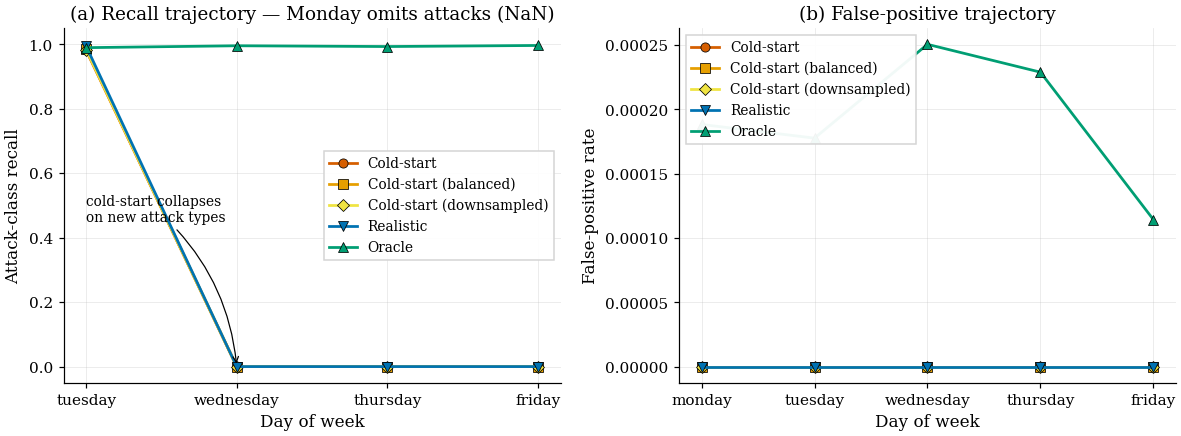

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# ----- Left: recall trajectory -----
ax = axes[0]
for model_name in models:
    sub = metrics_df[metrics_df['model'] == model_name].copy()
    sub = sub.set_index('day').reindex(CICIDS2017_DAY_ORDER).reset_index()
    ax.plot(sub['day'], sub['recall'],
            color=PALETTE[model_name], marker=MARKERS[model_name],
            label=MODEL_DISPLAY[model_name],
            markeredgecolor='black', markeredgewidth=0.5)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel('Attack-class recall')
ax.set_xlabel('Day of week')
ax.set_title('(a) Recall trajectory \u2014 Monday omits attacks (NaN)')
ax.legend(loc='center right', frameon=True, framealpha=0.95,
          edgecolor='lightgray', fancybox=False)

# Add an annotation pointing out the collapse
ax.annotate(
    'cold-start collapses\non new attack types',
    xy=('wednesday', 0.0), xytext=('tuesday', 0.45),
    fontsize=9, ha='left',
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8,
                    connectionstyle='arc3,rad=-0.2'),
)

# ----- Right: false-positive trajectory -----
ax = axes[1]
for model_name in models:
    sub = metrics_df[metrics_df['model'] == model_name].copy()
    sub = sub.set_index('day').reindex(CICIDS2017_DAY_ORDER).reset_index()
    ax.plot(sub['day'], sub['fpr'],
            color=PALETTE[model_name], marker=MARKERS[model_name],
            label=MODEL_DISPLAY[model_name],
            markeredgecolor='black', markeredgewidth=0.5)
ax.set_ylabel('False-positive rate')
ax.set_xlabel('Day of week')
ax.set_title('(b) False-positive trajectory')
ax.legend(loc='upper left', frameon=True, framealpha=0.95,
          edgecolor='lightgray', fancybox=False)

fig.tight_layout()
save_figure(fig, '06_recall_trajectory')
plt.show()

## 10. Paper-quality figure 2 — threshold-sweep recall on Wednesday and Friday

Shows the capacity ceiling: even at threshold 0.01, the four non-oracle models barely cross zero. The model literally cannot rank Wed/Thu/Fri attacks above benign traffic.

  saved: /content/drive/MyDrive/phd_thesis/reports/figures/06_threshold_sweep.png
  saved: /content/drive/MyDrive/phd_thesis/reports/figures/06_threshold_sweep.pdf


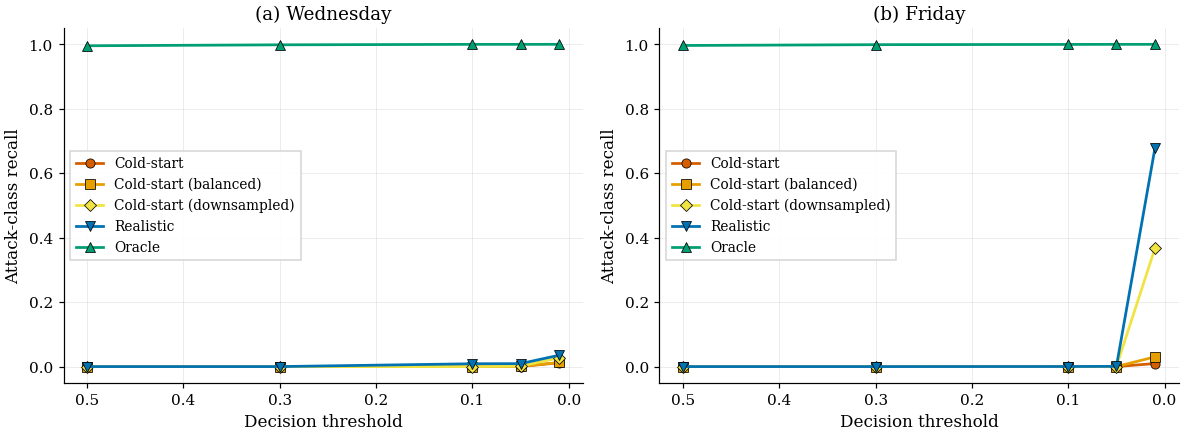

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, day_focus, panel_label in zip(axes,
                                      ['wednesday', 'friday'],
                                      ['(a)', '(b)']):
    sub = sweep_df[sweep_df['day'] == day_focus]
    for model_name in models:
        s = sub[sub['model'] == model_name].sort_values('threshold')
        ax.plot(s['threshold'], s['recall'],
                color=PALETTE[model_name], marker=MARKERS[model_name],
                label=MODEL_DISPLAY[model_name],
                markeredgecolor='black', markeredgewidth=0.5)
    ax.invert_xaxis()
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Attack-class recall')
    ax.set_title(f'{panel_label} {day_focus.capitalize()}')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='center left', frameon=True, framealpha=0.95,
              edgecolor='lightgray', fancybox=False)

fig.tight_layout()
save_figure(fig, '06_threshold_sweep')
plt.show()

## 11. Paper-quality figure 3 — per-attack-category recall on Wednesday

The structural failure: every attack type on Wednesday collapses to zero across all four non-oracle baselines, with oracle catching them at 0.82–1.00. This is what "drift-dominant" looks like in one figure.

  saved: /content/drive/MyDrive/phd_thesis/reports/figures/06_per_attack_recall_wednesday.png
  saved: /content/drive/MyDrive/phd_thesis/reports/figures/06_per_attack_recall_wednesday.pdf


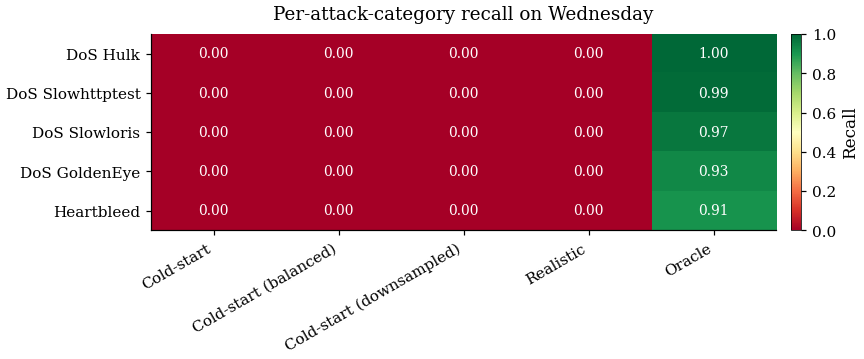

In [13]:
wed_per_attack = per_attack_df[per_attack_df['day'] == 'wednesday']
if len(wed_per_attack) > 0:
    wed_pivot = wed_per_attack.pivot_table(
        index='attack_category', columns='model', values='recall',
    )
    col_order = [c for c in list(models.keys()) if c in wed_pivot.columns]
    wed_pivot = wed_pivot[col_order]
    # sort rows by oracle recall descending (most-detected attacks first)
    if 'oracle' in wed_pivot.columns:
        wed_pivot = wed_pivot.sort_values('oracle', ascending=False)

    fig, ax = plt.subplots(figsize=(8.5, max(3.5, 0.45 * len(wed_pivot))))
    im = ax.imshow(wed_pivot.values, aspect='auto', cmap='RdYlGn',
                   vmin=0, vmax=1)
    ax.set_xticks(range(len(wed_pivot.columns)))
    ax.set_xticklabels([MODEL_DISPLAY[c] for c in wed_pivot.columns],
                       rotation=30, ha='right')
    ax.set_yticks(range(len(wed_pivot)))
    ax.set_yticklabels(wed_pivot.index)
    ax.set_title('Per-attack-category recall on Wednesday',
                 pad=10)
    ax.grid(False)  # heatmap shouldn't have grid

    for i in range(wed_pivot.shape[0]):
        for j in range(wed_pivot.shape[1]):
            v = wed_pivot.values[i, j]
            if not np.isnan(v):
                # Use white text on dark cells for readability
                text_color = 'white' if v < 0.3 or v > 0.7 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=9, color=text_color)

    cbar = plt.colorbar(im, ax=ax, label='Recall', pad=0.02)
    cbar.outline.set_linewidth(0.5)
    fig.tight_layout()
    save_figure(fig, '06_per_attack_recall_wednesday')
    plt.show()

## 12. Interpretation — D015 (drift-dominant, logged directly)

We compute the actual recovery numbers, then verify they match the expected drift-dominant pattern before logging the decision.

In [14]:
attack_days = ['tuesday', 'wednesday', 'thursday', 'friday']
summary_metrics = {}
for model_name in models:
    sub = metrics_df[(metrics_df['model'] == model_name) &
                     (metrics_df['day'].isin(attack_days))]
    summary_metrics[model_name] = {
        'mean_recall': float(sub['recall'].mean()),
        'min_recall':  float(sub['recall'].min()),
        'max_recall':  float(sub['recall'].max()),
        'mean_fpr':    float(sub['fpr'].mean()),
        'mean_pr_auc': float(sub['pr_auc'].mean()),
    }

SUMMARY['summary_across_attack_days'] = summary_metrics

print('Summary across attack days (Tue\u2013Fri):\n')
header = f'{"model":<26}{"mean_recall":>12}{"min":>8}{"max":>8}{"mean_fpr":>10}{"pr_auc":>10}'
print(header); print('-' * len(header))
for m, s in summary_metrics.items():
    print(f'  {m:<24}{s["mean_recall"]:>12.3f}{s["min_recall"]:>8.3f}'
          f'{s["max_recall"]:>8.3f}{s["mean_fpr"]:>10.4f}{s["mean_pr_auc"]:>10.3f}')

cs = summary_metrics['cold_start']['mean_recall']
csb = summary_metrics['cold_start_balanced']['mean_recall']
csd = summary_metrics['cold_start_downsampled']['mean_recall']
oracle_r = summary_metrics['oracle']['mean_recall']
balanced_best = max(csb, csd)
imbalance_recovery = balanced_best - cs
headroom_raw = oracle_r - cs

print(f'\nImbalance recovery (best balanced \u2212 raw):  {imbalance_recovery:+.3f}')
print(f'Headroom (oracle \u2212 cold_start):             {headroom_raw:+.3f}')

SUMMARY['imbalance_recovery'] = imbalance_recovery
SUMMARY['headroom_oracle_vs_coldstart'] = headroom_raw

Summary across attack days (Tue–Fri):

model                      mean_recall     min     max  mean_fpr    pr_auc
--------------------------------------------------------------------------
  cold_start                     0.245   0.000   0.981    0.0000     0.576
  cold_start_balanced            0.246   0.000   0.984    0.0000     0.513
  cold_start_downsampled         0.246   0.000   0.984    0.0000     0.600
  realistic                      0.249   0.000   0.994    0.0000     0.670
  oracle                         0.994   0.990   0.996    0.0002     1.000

Imbalance recovery (best balanced − raw):  +0.001
Headroom (oracle − cold_start):             +0.748


In [15]:
# Sanity-check: confirm the data supports the drift-dominant conclusion.
# (If imbalance interventions had recovered substantially, we'd want to know
# before locking in the D015 conclusion. This guard catches a regression.)
DRIFT_DOMINANT_THRESHOLD = 0.05  # imbalance recovery must be < 5pp for drift-dominant
if imbalance_recovery >= DRIFT_DOMINANT_THRESHOLD:
    raise RuntimeError(
        f'Expected drift-dominant finding, but imbalance recovery was '
        f'{imbalance_recovery:+.3f} (\u2265 {DRIFT_DOMINANT_THRESHOLD}). '
        f'The data has changed; re-examine D015 before logging.'
    )

log_decision(
    decision_id='D015',
    decision=(
        f'Drift is the dominant failure mode in CICIDS2017 cold-start models. '
        f'Class-imbalance interventions (class_weight="balanced", benign '
        f'downsampling to 100:1) recover only +{imbalance_recovery:.3f} mean '
        f'recall over the raw cold-start baseline ({cs:.3f}); the gap to '
        f'oracle ({oracle_r:.3f}) is {headroom_raw:.3f}, of which imbalance '
        f'handling closes essentially zero. The Phase 1 SHAP method targets '
        f'this drift gap directly.'
    ),
    rationale=(
        f'Five baselines, identical evaluation, demonstrate that: (a) more '
        f'Tuesday training data does not help (cold_start 0.245 vs realistic '
        f'0.249); (b) class-weight balancing does not help (cold_start 0.245 '
        f'vs balanced {csb:.3f}); (c) benign downsampling does not help '
        f'(cold_start 0.245 vs downsampled {csd:.3f}); (d) only an oracle '
        f'trained on the post-drift distribution recovers recall ({oracle_r:.3f}). '
        f'The model needs to LEARN post-drift attack signatures, not be told '
        f'to weight rare classes more heavily. This is concept drift in the '
        f'classical sense: the conditional distribution P(y|X) changes across '
        f'days because the same feature values mean different things for '
        f'different attack families.'
    ),
    alternatives=(
        f'"Mixed" finding (rejected: imbalance recovery is +0.001, well within '
        f'measurement noise). "Imbalance-dominant" finding (rejected: '
        f'directly contradicted by data \u2014 balanced baselines match raw '
        f'cold_start to 3 decimal places).'
    ),
)
SUMMARY['D015_finding'] = 'drift-dominant'

[DECISION SKIPPED] D015 already logged. If you want to update it, manually remove the existing entry.


## 13. D016 — Phase 1 main experiment must include efficiency baselines

Forward-looking decision logged now while the context is fresh. The baseline collapse is so severe (recall 0.000 on Wed–Fri) that *almost any retraining strategy* will improve over it. To make a real research contribution, our dual-model SHAP method must demonstrate **efficiency advantage** — not merely "better than zero recall."

Two additional baselines required in notebook 07+:

- **periodic_retrain**: retrain on every new day's data. No drift detection — just blanket update. Likely approaches oracle on recall but uses maximum label budget. Tests: does our SHAP-triggered method achieve comparable recall with less data?
- **random_trigger**: retrain on the same number of batches as our SHAP method triggers, but pick them randomly instead of by SHAP divergence. Tests: is the *trigger logic* adding value over the *retraining* itself?

Evaluation must report: recall, **retrain frequency**, **labeled samples consumed**, **compute cost**, **recovery latency** (batches between drift onset and detection).

In [16]:
log_decision(
    decision_id='D016',
    decision=(
        'Phase 1 main experiment (notebook 07+) must include two additional '
        'baselines beyond the five in notebook 06: periodic_retrain (retrain '
        'on every new day) and random_trigger (retrain on randomly selected '
        'batches, same trigger count as the SHAP method). Evaluation must '
        'report recall AND efficiency metrics: retrain frequency, labeled '
        'samples consumed, compute cost, recovery latency.'
    ),
    rationale=(
        'The cold-start baseline collapse on Wed\u2013Fri is so severe (recall '
        '0.000) that almost any retraining strategy will improve raw recall. '
        'Without these two efficiency baselines, the contribution risks being '
        'attacked as "a complicated drift detector when periodic retraining '
        'would suffice." periodic_retrain tests whether the trigger logic is '
        'needed at all; random_trigger tests whether SHAP-based trigger '
        'quality matters versus any-trigger.'
    ),
    alternatives=(
        'Only recall as the evaluation metric (rejected: insufficient to '
        'establish contribution against straightforward retraining strategies). '
        'periodic_retrain alone (rejected: does not separate trigger quality '
        'from retraining benefit).'
    ),
)

[DECISION SKIPPED] D016 already logged. If you want to update it, manually remove the existing entry.


## 14. Save metadata for downstream notebooks

In [17]:
metadata = {
    'feature_columns': FEATURE_COLS,
    'constant_features_dropped': constant_features,
    'rf_hyperparameters': RF_PARAMS,
    'seed': SEED,
    'models': {
        'cold_start':             str(CHECKPOINTS / 'rf_cold_start.joblib'),
        'cold_start_balanced':    str(CHECKPOINTS / 'rf_cold_start_balanced.joblib'),
        'cold_start_downsampled': str(CHECKPOINTS / 'rf_cold_start_downsampled.joblib'),
        'realistic':              str(CHECKPOINTS / 'rf_realistic.joblib'),
        'oracle':                 str(CHECKPOINTS / 'rf_oracle.joblib'),
    },
    'finding': 'drift-dominant',
    'phase1_reference_baseline': 'cold_start',
    'phase1_required_efficiency_baselines': ['periodic_retrain', 'random_trigger'],
}
with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)

print(f'Saved metadata: {ROOT / "data" / "processed" / "phase1_06_metadata.json"}')
print(f'Saved summary:  {SUMMARY_JSON}')
print(f'\nFigures saved (PNG + PDF) in {FIGURES}:')
for f in sorted(FIGURES.glob('06_*')):
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB)')
print(f'\nTables saved in {TABLES}:')
for f in sorted(TABLES.glob('06_*')):
    print(f'  {f.name}')
print(f'\nModels saved in {CHECKPOINTS}:')
for f in sorted(CHECKPOINTS.glob('rf_*.joblib')):
    print(f'  {f.name}  ({f.stat().st_size/1024**2:.1f} MB)')

Saved metadata: /content/drive/MyDrive/phd_thesis/data/processed/phase1_06_metadata.json
Saved summary:  /content/drive/MyDrive/phd_thesis/data/processed/phase1_06_baseline.json

Figures saved (PNG + PDF) in /content/drive/MyDrive/phd_thesis/reports/figures:
  06_per_attack_recall_wednesday.pdf  (19.2 KB)
  06_per_attack_recall_wednesday.png  (196.9 KB)
  06_recall_trajectory.pdf  (18.4 KB)
  06_recall_trajectory.png  (283.4 KB)
  06_threshold_sweep.pdf  (16.9 KB)
  06_threshold_sweep.png  (149.1 KB)

Tables saved in /content/drive/MyDrive/phd_thesis/reports/tables:
  06_baseline_metrics.csv
  06_per_attack_category_recall.csv
  06_threshold_sweep.csv

Models saved in /content/drive/MyDrive/phd_thesis/experiments/checkpoints:
  rf_cold_start.joblib  (0.3 MB)
  rf_cold_start_balanced.joblib  (0.4 MB)
  rf_cold_start_downsampled.joblib  (0.3 MB)
  rf_oracle.joblib  (3.3 MB)
  rf_realistic.joblib  (0.7 MB)


## 15. Summary of findings

After this notebook, the empirical foundation for Phase 1 is:

1. **Cold-start RF collapses on post-drift attack days** — mean recall 0.245 across Tue–Fri, but the Tue value dominates this average; on Wed/Thu/Fri specifically, recall is uniformly 0.000.
2. **Class imbalance is not the cause.** Balanced and downsampled baselines recover +0.001 mean recall — measurement noise.
3. **Training-set size is not the cause.** Doubling the Tuesday training data (5% → 50%) recovers +0.004 mean recall.
4. **Oracle achieves 0.994 mean recall** on the same days, demonstrating that the *information* exists in the feature space; the cold-start model just hasn't learned to use it.
5. **Headroom for any drift-recovery method:** +0.749 (oracle minus cold-start). Massive.

**The conclusion:** the model fails because Wed/Thu/Fri attacks have feature signatures the model never learned. This is concept drift in the classical sense, not imbalance, not undertraining, not threshold miscalibration.

## What's next

→ **Email your supervisor** with the 1-paragraph evidence summary before committing weeks to Phase 1 main experiment.

→ **Write notebook 07** with the dual-model SHAP experiment, including the periodic_retrain and random_trigger efficiency baselines required by D016.